In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sci

In [77]:
load_path = Path(os.environ["WORK"], "hypo_sleep/processed_data/mat_spectra_res/")
save_path = Path(os.environ["WORK"], "hypo_sleep/figures")

In [53]:
def grand_average_tfr(tfr_list):
    """
    tfr_list: list of FieldTrip freq structs
    """
    pow_stack = np.stack([t.powspctrm for t in tfr_list], axis=0)
    return np.nanmean(pow_stack, axis=0), tfr_list[0].freq, tfr_list[0].time

In [ ]:
load_key = "ft_statfun_actvsblT"
stat_data = sci.loadmat(
    Path(load_path, f"tfr_stats_{load_key}.mat"),
    squeeze_me=True,
    struct_as_record=False,
)
tfr_data = sci.loadmat(
    Path(load_path, f"avg_tfr_{load_key}.mat"), squeeze_me=True, struct_as_record=False
)
animals = [
    "HYDO03",
]  # "HYDO04"]
triggers = ["so", "spi", "nrem"]

/tmp/ipykernel_3873174/1383106327.py:6: RuntimeWarning: Mean of empty slice
  return np.nanmean(pow_stack, axis=0), tfr_list[0].freq, tfr_list[0].time


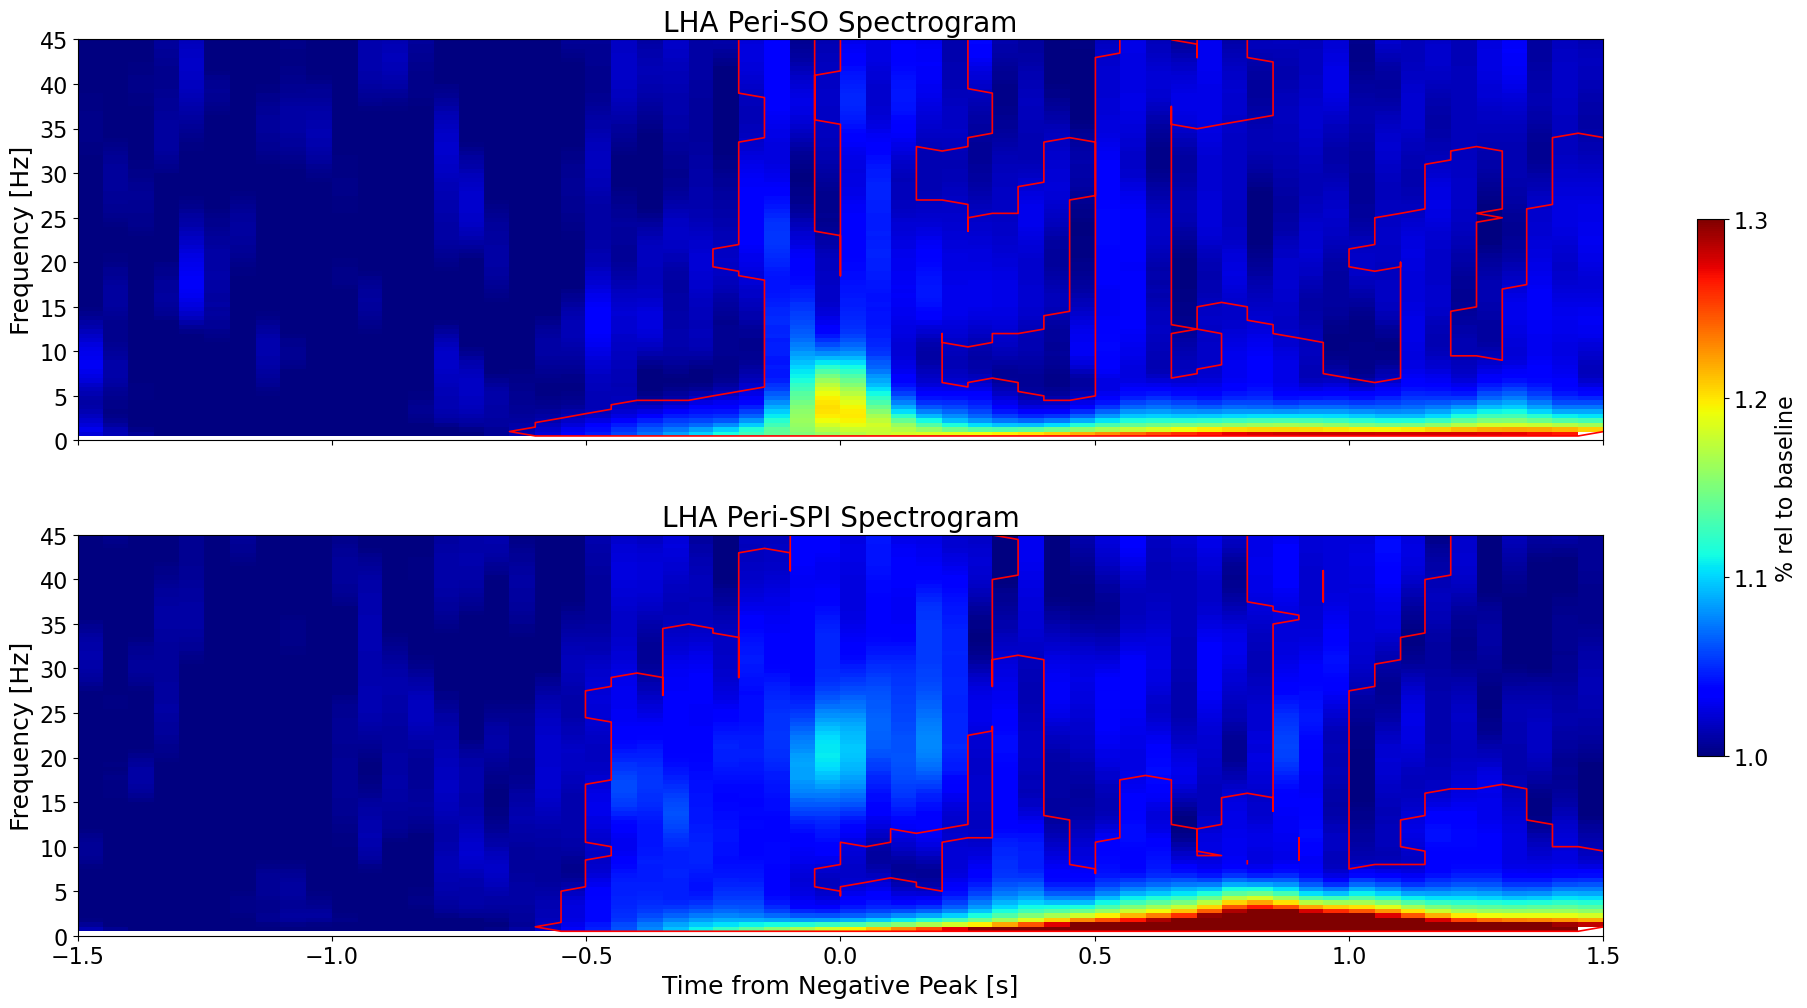

In [93]:
fig, axs = plt.subplots(
    nrows=2, figsize=(18, 10), constrained_layout=True, sharex=True, sharey=True
)
for animal in animals:
    for ax, tmp_trig in zip(axs.ravel(), ["so", "spi"]):

        peak_tfrs = getattr(tfr_data[animal], tmp_trig).peak
        # lfp_list = getattr(stat_data[animal], trig).lfp if trig != "nrem" else None

        # ---- TFR grand average ----
        pow_avg, freqs, times = grand_average_tfr(peak_tfrs)

        # ---- Stats ----
        stat = getattr(stat_data[animal], tmp_trig)
        sig_pos = stat.sig_pos
        sig_neg = stat.sig_neg
        xx, yy = np.meshgrid(times, freqs)
        h1 = ax.pcolormesh(
            xx,
            yy,
            pow_avg[1:, 1:],
            cmap="jet",
            shading="flat",
            vmin=1.0,
            vmax=1.3,
        )

        # if tmp_trig in ["so", "spi"]:
        if np.any(sig_pos):
            ax.contour(
                xx,
                yy,
                sig_pos,
                colors="red",
                levels=[0.0],
                linewidths=1.2,
            )
        if np.any(sig_neg):
            ax.contour(
                xx,
                yy,
                sig_neg,
                colors="green",
                levels=[0.0],
                linewidths=1.2,
            )
        ax.set_ylim([0, 45])
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylabel("Frequency [Hz]", fontsize=18)
        ax.set_title(f"LHA Peri-{tmp_trig.upper()} Spectrogram", fontsize=20)
        ax.tick_params(axis="both", labelsize=16)
    cbar = fig.colorbar(
        h1,
        ax=axs.ravel().tolist(),
        ticks=np.arange(1.0, 1.4, 0.1),
        shrink=0.6,
    )
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label("% rel to baseline", fontsize=16)

    fig.get_layout_engine().set(
        h_pad=4 / 72,
        hspace=0.1,
    )
    ax.set_xlabel("Time from Negative Peak [s]", fontsize=18)
    fig.savefig(
        Path(save_path, f"{animal}_peri_so_spi_tfr.png"),
        dpi=500,
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
    )